# NFL 4th Down — WPA Baselines
Compute historically weighted WPA baselines per game state, assign the optimal decision
to every play, and quantify how much value each coach left on the table.

**Inputs:** `data/fourth_downs_clean.parquet`  
**Outputs:** `data/fourth_downs_graded.parquet`, two charts in `outputs/figures/`

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from features import add_game_state_bins
from grading import compute_wpa_baselines, assign_optimal_decision

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

SAVE_DIR = '../outputs/figures/'
DATA_DIR = '../data/'

## 1. Load Cleaned Data

In [2]:
fourth = pd.read_parquet(DATA_DIR + 'fourth_downs_clean.parquet')

print(f'Shape: {fourth.shape}')
print(f'Seasons: {fourth["season"].min()} – {fourth["season"].max()}')
print(f'Decisions: {fourth["decision"].value_counts().to_dict()}')
fourth.head(3)

Shape: (107189, 45)
Seasons: 1999 – 2025
Decisions: {'punt': 66137, 'field_goal': 25455, 'go_for_it': 15597}


,play_id,game_id,season,week,game_date,posteam,defteam,home_team,away_team,down,...,roof,surface,temp,wind,spread_line,total_line,decision,recency_weight,ydstogo_bucket,yardline_bucket
0,150,1999_01_ARI_PHI,1999,1,1999-09-12,PHI,ARI,PHI,ARI,4.0,...,outdoors,astroturf,75.0,3.0,-3.0,37.0,punt,0.014618,4-5,60-80
1,240,1999_01_ARI_PHI,1999,1,1999-09-12,ARI,PHI,PHI,ARI,4.0,...,outdoors,astroturf,75.0,3.0,-3.0,37.0,punt,0.014618,4-5,60-80
2,561,1999_01_ARI_PHI,1999,1,1999-09-12,ARI,PHI,PHI,ARI,4.0,...,outdoors,astroturf,75.0,3.0,-3.0,37.0,punt,0.014618,8+,60-80


## 2. Apply Game State Bins
Bins are defined in `src/features.py` and match the spec in `PLAN.md` exactly.
Each play gets a composite `game_state_key` used as the baseline lookup key.

In [3]:
fourth = add_game_state_bins(fourth)

print(f'Unique game state keys: {fourth["game_state_key"].nunique():,}')
print('\nField position distribution:')
print(fourth['field_pos_bin'].value_counts().sort_index())
print('\nYards-to-go distribution:')
print(fourth['ydstogo_bin'].value_counts().sort_index())

Unique game state keys: 699

Field position distribution:
field_pos_bin
red_zone         17645
opp_territory    20094
midfield         26548
own_territory    32416
deep_own         10486
Name: count, dtype: int64

Yards-to-go distribution:
ydstogo_bin
short_1       12073
short_2_3     16421
medium_4_6    24266
long_7plus    54429
Name: count, dtype: int64


## 3. Compute WPA Baselines
For each `game_state_key × decision` cell, compute the **recency-weighted average WPA**
(decay = 0.85/yr, anchored at the most recent season).  
Cells with fewer than 10 plays are dropped as unreliable.

In [4]:
baselines = compute_wpa_baselines(fourth, weight_col='recency_weight')

print(f'\nBaseline table shape: {baselines.shape}')
print('\nSample rows (sorted by mean_wpa desc):')
baselines.sort_values('mean_wpa', ascending=False).head(8)

WPA baselines computed: 947 game_state × decision cells

Baseline table shape: (947, 4)

Sample rows (sorted by mean_wpa desc):


,game_state_key,decision,mean_wpa,n_plays
329,midfield|medium_4_6|tied|late_4th,punt,0.152087,35.0
30,deep_own|long_7plus|tied|late_4th,punt,0.147634,47.0
934,own_territory|long_7plus|tied|late_4th,punt,0.138248,124.0
733,opp_territory|short_1|down_close|two_min_drill,field_goal,0.132138,20.0
253,midfield|long_7plus|tied|late_4th,punt,0.122032,109.0
1381,red_zone|short_2_3|tied|two_min_drill,field_goal,0.109891,16.0
757,opp_territory|short_1|tied|two_min_drill,field_goal,0.107175,11.0
852,opp_territory|short_2_3|tied|two_min_drill,field_goal,0.106399,31.0


In [5]:
# Coverage: how many unique game states have at least one qualified decision?
covered = baselines['game_state_key'].nunique()
total   = fourth['game_state_key'].nunique()
plays_covered = fourth[fourth['game_state_key'].isin(baselines['game_state_key'])].shape[0]

print(f'Game states with baselines : {covered:,} / {total:,} ({covered/total*100:.1f}%)')
print(f'Plays covered by a baseline: {plays_covered:,} / {len(fourth):,} ({plays_covered/len(fourth)*100:.1f}%)')

Game states with baselines : 656 / 699 (93.8%)
Plays covered by a baseline: 106,942 / 107,189 (99.8%)


## 4. Assign Optimal Decision
For every play, look up the highest-WPA decision in its game state bucket.
Adds: `optimal_decision`, `optimal_wpa`, `baseline_actual_wpa`, `decision_gap`, `made_optimal`.

In [6]:
fourth = assign_optimal_decision(fourth, baselines)

graded = fourth.dropna(subset=['decision_gap'])
print(f'Plays with a valid decision gap: {len(graded):,} ({len(graded)/len(fourth)*100:.1f}%)')
print(f'\nMean decision gap (lower = closer to optimal): {graded["decision_gap"].mean():.4f}')
print(f'Overall Optimal Decision Rate             : {graded["made_optimal"].mean()*100:.1f}%')

Plays with a valid decision gap: 105,544 (98.5%)

Mean decision gap (lower = closer to optimal): 0.0085
Overall Optimal Decision Rate             : 67.0%


In [7]:
# Optimal decision rate by decision type
print('Made-optimal rate by actual decision chosen:')
print(
    graded.groupby('decision')['made_optimal']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'odr', 'count': 'n'})
    .assign(odr=lambda x: (x['odr'] * 100).round(1))
    .sort_values('odr', ascending=False)
)

Made-optimal rate by actual decision chosen:
             odr      n
decision               
go_for_it   84.2  14655
field_goal  67.9  25214
punt        62.8  65675


## 5. Validation — Spot Check Known Situations
Sanity check that the baselines pass the smell test on a few well-known situations.

In [8]:
def lookup_optimal(field_pos_bin, ydstogo_bin, score_diff_bin, time_bin):
    """Print the WPA table for a specific game state."""
    key = f'{field_pos_bin}|{ydstogo_bin}|{score_diff_bin}|{time_bin}'
    rows = baselines[baselines['game_state_key'] == key].sort_values('mean_wpa', ascending=False)
    if rows.empty:
        print(f'No baseline data for: {key}')
        return
    print(f'Game state: {key}')
    print(rows[['decision', 'mean_wpa', 'n_plays']].to_string(index=False))
    print()

# yardline_100 bins (corrected): red_zone=0-20, opp_territory=20-40, midfield=40-60,
#                                  own_territory=60-80, deep_own=80-100

# 4th & 1 at opp 35 (yardline_100≈35 → opp_territory), tied, 4th quarter → should be go_for_it
lookup_optimal('opp_territory', 'short_1', 'tied', '4th_quarter')

# 4th & 8 at own 25 (yardline_100≈75 → own_territory), tied, second_half → should be punt
lookup_optimal('own_territory', 'long_7plus', 'tied', 'second_half')

# 4th & 4 at opp 18 (yardline_100≈18 → red_zone), tied, 4th_quarter → should be field_goal
lookup_optimal('red_zone', 'medium_4_6', 'tied', '4th_quarter')

# 4th & 1 at own 40 (yardline_100≈60 → midfield), down big, late_4th → should be go_for_it
lookup_optimal('midfield', 'short_1', 'down_big', 'late_4th')

Game state: opp_territory|short_1|tied|4th_quarter
  decision  mean_wpa  n_plays
field_goal  0.076248     11.0
 go_for_it  0.053517     25.0

Game state: own_territory|long_7plus|tied|second_half
decision  mean_wpa  n_plays
    punt  0.035024    357.0

Game state: red_zone|medium_4_6|tied|4th_quarter
  decision  mean_wpa  n_plays
field_goal -0.008477     57.0

Game state: midfield|short_1|down_big|late_4th
 decision  mean_wpa  n_plays
go_for_it  0.011931     76.0



## 6. Chart — Optimal Decision Heatmap
What *should* teams do across field position and distance, in the modal game state
(tied score, 4th quarter)?

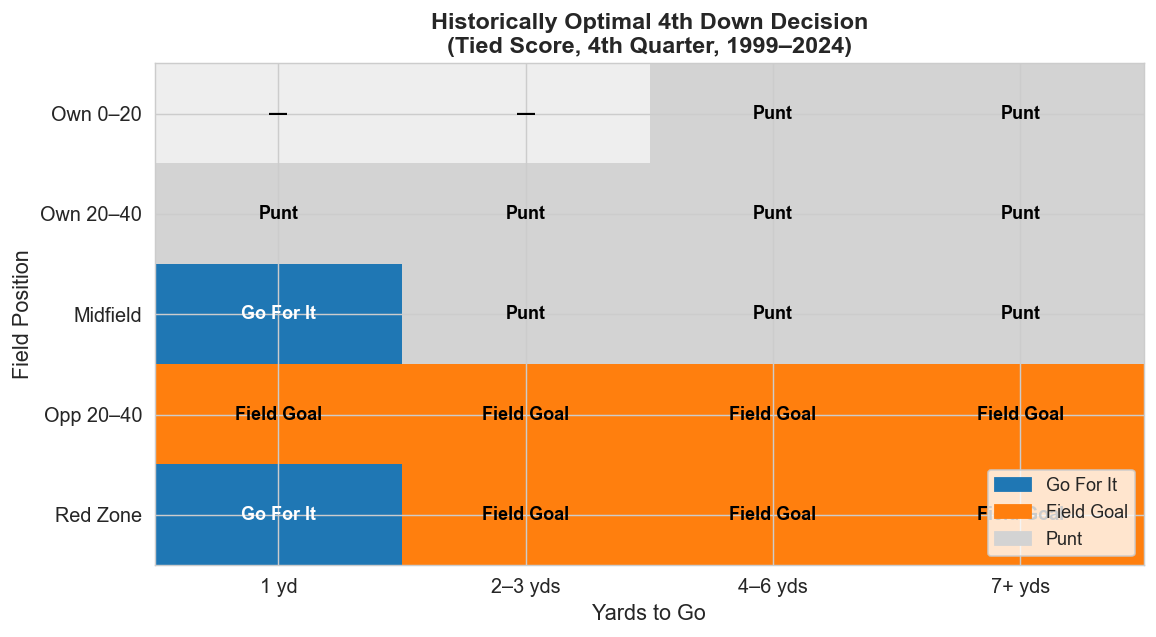

In [9]:
# Filter baselines to tied / 4th quarter for the heatmap
SCORE_BIN = 'tied'
TIME_BIN  = '4th_quarter'

field_order  = ['deep_own', 'own_territory', 'midfield', 'opp_territory', 'red_zone']
ydstogo_order = ['short_1', 'short_2_3', 'medium_4_6', 'long_7plus']

# Get the optimal decision for each field_pos × ydstogo cell
records = []
for fp in field_order:
    for yd in ydstogo_order:
        key = f'{fp}|{yd}|{SCORE_BIN}|{TIME_BIN}'
        rows = baselines[baselines['game_state_key'] == key]
        if rows.empty:
            records.append({'field_pos': fp, 'ydstogo': yd, 'optimal': 'no data'})
        else:
            best = rows.loc[rows['mean_wpa'].idxmax()]
            records.append({'field_pos': fp, 'ydstogo': yd,
                            'optimal': best['decision'], 'wpa': best['mean_wpa']})

hm_df = pd.DataFrame(records)

# Map decisions to numbers for color encoding
dec_map   = {'go_for_it': 0, 'field_goal': 1, 'punt': 2, 'no data': 3}
colors    = ['#1f77b4', '#ff7f0e', '#d3d3d3', '#ffffff']
cmap      = plt.cm.colors.ListedColormap(colors) if False else None

pivot = (
    hm_df.pivot(index='field_pos', columns='ydstogo', values='optimal')
    .reindex(index=field_order, columns=ydstogo_order)
)
pivot_num = pivot.map(lambda x: dec_map.get(x, 3))

fig, ax = plt.subplots(figsize=(9, 5))
import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(['#1f77b4', '#ff7f0e', '#d3d3d3', '#eeeeee'])

im = ax.imshow(pivot_num.values, cmap=cmap, vmin=0, vmax=3, aspect='auto')

# Annotate each cell with the decision label
label_map = {'go_for_it': 'Go For It', 'field_goal': 'Field Goal',
             'punt': 'Punt', 'no data': '—'}
for i, fp in enumerate(field_order):
    for j, yd in enumerate(ydstogo_order):
        val = pivot.iloc[i, j]
        txt_color = 'white' if val == 'go_for_it' else 'black'
        ax.text(j, i, label_map.get(val, val), ha='center', va='center',
                fontsize=10, fontweight='bold', color=txt_color)

ax.set_xticks(range(len(ydstogo_order)))
ax.set_xticklabels(['1 yd', '2–3 yds', '4–6 yds', '7+ yds'], fontsize=11)
ax.set_yticks(range(len(field_order)))
ax.set_yticklabels(['Own 0–20', 'Own 20–40', 'Midfield', 'Opp 20–40', 'Red Zone'], fontsize=11)
ax.set_xlabel('Yards to Go', fontsize=12)
ax.set_ylabel('Field Position', fontsize=12)
ax.set_title('Historically Optimal 4th Down Decision\n(Tied Score, 4th Quarter, 1999–2024)',
             fontsize=13, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#1f77b4', label='Go For It'),
    mpatches.Patch(color='#ff7f0e', label='Field Goal'),
    mpatches.Patch(color='#d3d3d3', label='Punt'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}04_optimal_decision_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Chart — Optimal vs Actual Decision Rate by Season
How often did teams make the historically optimal call, and how has that changed over time?

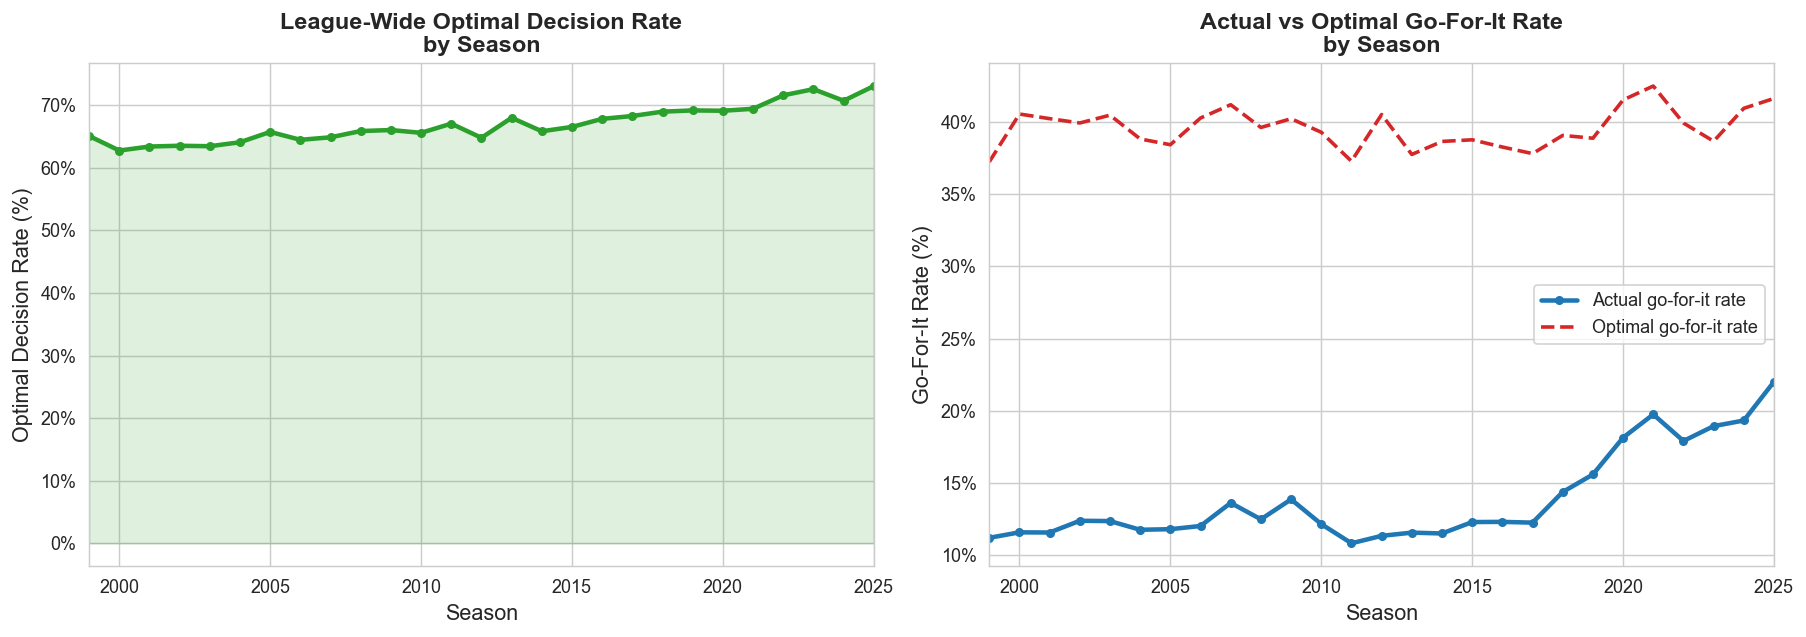


Recent seasons (last 5):
 season  odr  go_rate  optimal_go_rate    n
   2021 69.4     19.8             42.5 3912
   2022 71.6     17.9             39.9 3990
   2023 72.6     18.9             38.7 4159
   2024 70.7     19.3             40.9 3920
   2025 73.1     22.0             41.6 3887


In [10]:
by_season = (
    graded.groupby('season')
    .agg(
        odr=('made_optimal', 'mean'),
        go_rate=('decision', lambda x: (x == 'go_for_it').mean()),
        optimal_go_rate=('optimal_decision', lambda x: (x == 'go_for_it').mean()),
        n=('decision', 'count'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ODR over time
ax = axes[0]
ax.plot(by_season['season'], by_season['odr'] * 100,
        color='#2ca02c', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(by_season['season'], by_season['odr'] * 100,
                alpha=0.15, color='#2ca02c')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Optimal Decision Rate (%)', fontsize=12)
ax.set_title('League-Wide Optimal Decision Rate\nby Season', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.set_xlim(by_season['season'].min(), by_season['season'].max())

# Right: Actual go-for-it rate vs optimal go-for-it rate
ax = axes[1]
ax.plot(by_season['season'], by_season['go_rate'] * 100,
        color='#1f77b4', linewidth=2.5, marker='o', markersize=4, label='Actual go-for-it rate')
ax.plot(by_season['season'], by_season['optimal_go_rate'] * 100,
        color='#d62728', linewidth=2, linestyle='--', label='Optimal go-for-it rate')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Go-For-It Rate (%)', fontsize=12)
ax.set_title('Actual vs Optimal Go-For-It Rate\nby Season', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.set_xlim(by_season['season'].min(), by_season['season'].max())
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}05_optimal_vs_actual_by_season.png', bbox_inches='tight')
plt.show()

print('\nRecent seasons (last 5):')
print(by_season.tail(5)[['season','odr','go_rate','optimal_go_rate','n']]
      .assign(odr=lambda x: (x['odr']*100).round(1),
              go_rate=lambda x: (x['go_rate']*100).round(1),
              optimal_go_rate=lambda x: (x['optimal_go_rate']*100).round(1))
      .to_string(index=False))

## 8. Save Graded Dataset

In [11]:
out_path = DATA_DIR + 'fourth_downs_graded.parquet'
fourth.to_parquet(out_path, index=False)

print(f'Saved {len(fourth):,} rows → {out_path}')
print(f'Columns added: optimal_decision, optimal_wpa, baseline_actual_wpa, decision_gap, made_optimal')
print(f'Null decision_gap: {fourth["decision_gap"].isna().sum():,} plays (game states with no baseline)')

Saved 107,189 rows → ../data/fourth_downs_graded.parquet
Columns added: optimal_decision, optimal_wpa, baseline_actual_wpa, decision_gap, made_optimal
Null decision_gap: 1,645 plays (game states with no baseline)
